In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_excel("S3-4_Capstone_Task_Pick_dataset_define_3_questions_set_up_skeleton_notebook.xlsx")
# we have loaded the dataset

df["Date"] = pd.to_datetime(df["Date"])
#we have converted our date to datetime object because this date is considered as normal text if we dont 
#convert it into the datetime object and also the extraction of the month, year, date will be very difficult for with the existing format

df.head()
# first 5 rows

,Order ID,Date,Customer ID,Region,Category,Product,Quantity,Price
0,1001,2023-01-01 00:00:00.000000000,CUST0103,North,Electronics,Laptop,2,3079
1,1002,2023-01-01 08:44:41.081081081,CUST0180,South,Groceries,Shirt,1,4869
2,1003,2023-01-01 17:29:22.162162162,CUST0093,West,Electronics,Shoes,5,1836
3,1004,2023-01-02 02:14:03.243243243,CUST0015,South,Fashion,TV,4,3711
4,1005,2023-01-02 10:58:44.324324324,CUST0107,West,Electronics,Headphones,5,2353


In [ ]:
# Q1 What is total revenue?

df["Revenue"] = df["Quantity"] * df["Price"]
# new column named Revenue is created which is product of quality and price and now we simply add the revenues to find the totl revenue

total_revenue = df["Revenue"].sum()

print("Total Revenue is :₹", total_revenue)


Total Revenue is :₹ 7615870


Month
1           NaN
2    -14.094105
3     18.153722
4     -3.809101
5      4.784528
6    -10.272125
7      5.013060
8     -5.557201
9     -0.076359
10     1.974171
11   -11.254733
12    13.966838
Name: Revenue, dtype: float64


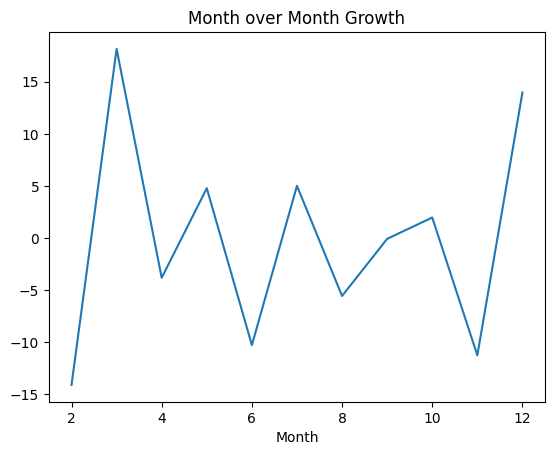

In [ ]:
#Q2 What is month-over-month growth?

df["Month"] = df["Date"].dt.month
# print(df["Month"])

monthly_sales = df.groupby("Month")["Revenue"].sum()
# print(monthly_sales)

mom_growth = monthly_sales.pct_change() * 100
print(mom_growth)


# GRAPH
mom_growth.plot()
plt.title("Month over Month Growth")

plt.show()

Year
2023   NaN
Name: Revenue, dtype: float64


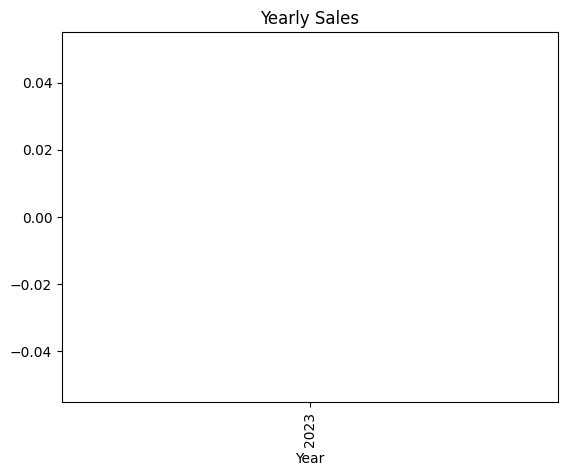

In [60]:
# Q3 What is year-over-year growth?

df["Year"] = df["Date"].dt.year
# print(df["Year"])

yearly_sales = df.groupby("Year")["Revenue"].sum()
# print(yearly_sales)

yoy_growth = yearly_sales.pct_change() * 100
print(yoy_growth)



# GRAPH
yoy_growth.plot.bar()
plt.title("Yearly Sales")

plt.show()

Hour
0     43
1     42
2     41
3     42
4     42
5     41
6     42
7     41
8     42
9     42
10    41
11    42
12    42
13    41
14    42
15    41
16    42
17    42
18    41
19    42
20    42
21    41
22    42
23    41
Name: Order ID, dtype: int64
Most Ordered Hour : 0


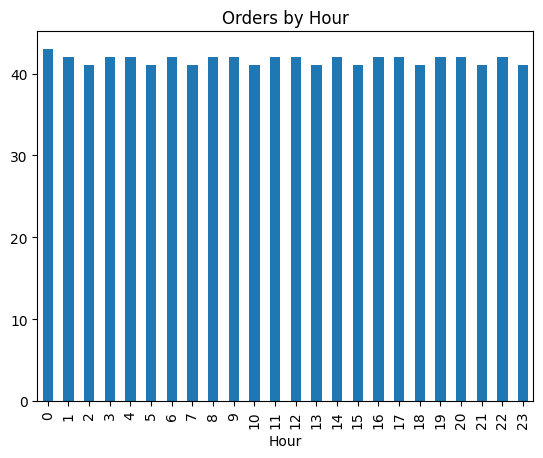

In [ ]:
# Question 4: What is the most ordered time-window?
df["Hour"] = df["Date"].dt.hour

# Count orders by hour
orders = df.groupby("Hour")["Order ID"].count()

print(orders)
print("Most Ordered Hour :", orders.idxmax())




# GRAPH
orders.plot.bar()
plt.title("Orders by Hour")

plt.show()

In [ ]:
# Q5 What is customer lifetime value?

# each customer lifetime value
customer_value = df.groupby("Customer ID")["Revenue"].sum()
print(customer_value)

# average lifetime value of all customers
cltv = customer_value.mean()
print("Average lifetime value of a customers: ₹",cltv)


Customer ID
CUST0001    46448
CUST0002    47853
CUST0003    45201
CUST0004    48110
CUST0005    32584
            ...  
CUST0195    23604
CUST0196     9276
CUST0197    40714
CUST0198    39542
CUST0199    12234
Name: Revenue, Length: 197, dtype: int64
Average lifetime value of a customers: ₹ 38659.238578680204


In [36]:
# Q6 What is customer churn rate?

last_purchase = df.groupby("Customer ID")["Date"].max()
print(last_purchase)

Customer ID
CUST0001   2023-12-11 07:47:01.621621624
CUST0002   2023-07-16 09:25:02.702702704
CUST0003   2023-12-18 05:56:02.162162164
CUST0004   2023-10-27 20:55:29.729729732
CUST0005   2023-11-30 09:26:29.189189192
                        ...             
CUST0195   2023-11-26 17:59:38.378378380
CUST0196   2023-07-30 23:12:25.945945948
CUST0197   2023-10-21 16:15:51.351351352
CUST0198   2023-03-29 01:59:38.378378379
CUST0199   2023-08-16 08:43:14.594594596
Name: Date, Length: 197, dtype: datetime64[ns]


In [38]:
# Q7 What is average order value?

order_value = df.groupby("Order ID")["Revenue"].sum()

average_order_value = order_value.mean()
# this will give us the average order value of all the customers.

print("Average Order Value :₹", average_order_value)

Average Order Value :₹ 7615.87


Sales per Region: Region
East     1928234
North    2008809
South    1934023
West     1744804
Name: Revenue, dtype: int64


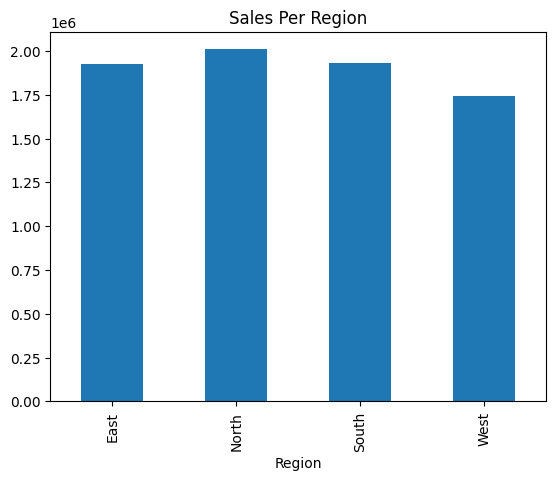

Sales per category Category
Electronics    1924630
Fashion        1957940
Furniture      1958341
Groceries      1774959
Name: Revenue, dtype: int64


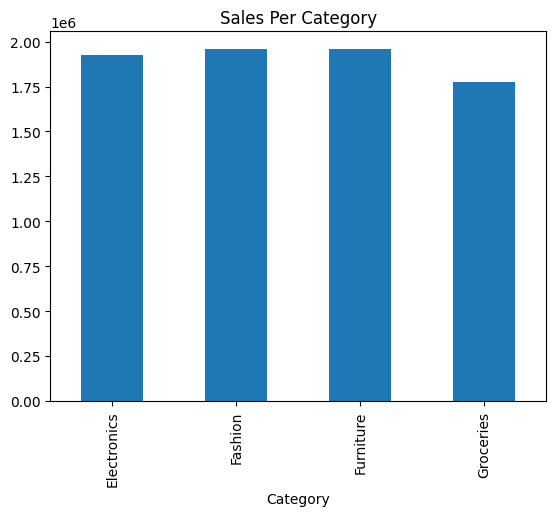

Sales per product Product
Headphones    721570
Laptop        810850
Mobile        707292
Rice          712945
Shirt         826066
Shoes         827300
Sofa          668296
TV            746419
Table         745932
Watch         849200
Name: Revenue, dtype: int64


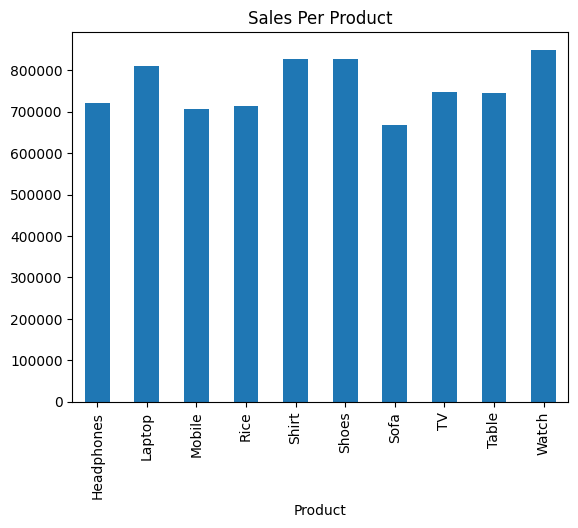

In [66]:
#Q8: What are the sales per Region, Category, and Product?

# Sales per Region
region_sales = df.groupby("Region")["Revenue"].sum()
print("Sales per Region:",region_sales)

# GRAPH
region_sales.plot.bar()
plt.title("Sales Per Region")
plt.show()





# Sales per category
category_sales = df.groupby("Category")["Revenue"].sum()
print("Sales per category", category_sales)

# GRAPH
category_sales.plot.bar()
plt.title("Sales Per Category")
plt.show()





# Sales per product
product_sales = df.groupby("Product")["Revenue"].sum()
print("Sales per product", product_sales)

# GRAPH
product_sales.plot.bar()
plt.title("Sales Per Product")
plt.show()

In [46]:
# Q9: Which products have declining sales?

df["Month"] = df["Date"].dt.month
product_sales = df.groupby(["Month", "Product"])["Revenue"].sum().reset_index()

print(product_sales)

change = product_sales.groupby("Product")["Revenue"].diff()

product_sales["Sales Change"] = change

declining_products = product_sales[product_sales["Sales Change"] < 0]

print(declining_products)

     Month     Product  Revenue
0        1  Headphones    52298
1        1      Laptop    52707
2        1      Mobile   132718
3        1        Rice    20286
4        1       Shirt   103241
..     ...         ...      ...
115     12       Shoes    71359
116     12        Sofa    31258
117     12          TV    48365
118     12       Table    28891
119     12       Watch   101111

[120 rows x 3 columns]
     Month     Product  Revenue  Sales Change
12       2      Mobile    51112      -81606.0
14       2       Shirt    36989      -66252.0
15       2       Shoes    60793      -47621.0
16       2        Sofa    22624      -53007.0
18       2       Table    12067      -42427.0
20       3  Headphones    72231      -21681.0
23       3        Rice    66529      -15466.0
27       3          TV    25009      -59573.0
31       4      Laptop    37782      -61783.0
32       4      Mobile    60733       -5078.0
33       4        Rice    45924      -20605.0
34       4       Shirt    63866       -8

     Month     Product  Quantity
2        1      Mobile        47
13       2        Rice        35
29       3       Watch        42
30       4  Headphones        31
45       5       Shoes        42
58       6       Table        43
60       7  Headphones        36
73       8        Rice        28
88       9       Table        43
91      10      Laptop        48
104     11       Shirt        35
113     12        Rice        37


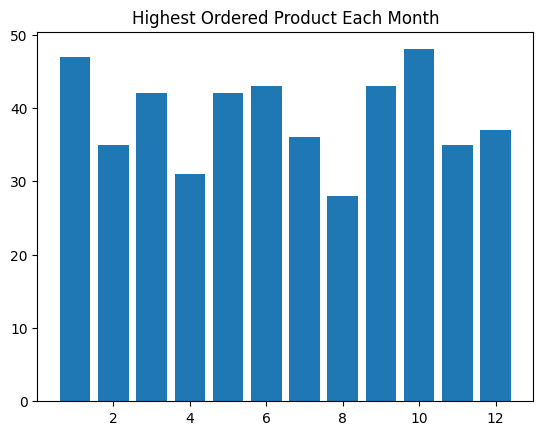

In [67]:
# Q10 Product vs month evaluation, which product is being ordered most ?

x = df.groupby(["Month", "Product"])["Quantity"].sum().reset_index()

y = x.loc[x.groupby("Month")["Quantity"].idxmax()]

print(y)


# GRAPH
plt.bar(y["Month"], y["Quantity"])
plt.title("Highest Ordered Product Each Month")
plt.show()